# Objective 4 — System Evaluation

Evaluate CyREN as a SOC-automation system. Four metrics were scoped; this
notebook computes the **two that the current data fully supports**:

1. **Automation rate** — share of events the system handles automatically
   (high → auto-block, low → auto-log) vs. those routed to a human
   (uncertain → approval queue).
2. **False-positive identification rate** — how well the triage classifier
   (XGBoost, from Objective 3) recognises benign traffic (false positives),
   i.e. the **recall on the benign class**.

The other two (**MTTR**, **MTTD**) need extra timestamp instrumentation and are
handled separately (Event.ingested_at + a live run for MTTR; an Elasticsearch
alert-index query for MTTD).

## Setup
Run from the repo root so `app` imports and `data/cyren.db` resolve (works whether launched from the repo root or from `notebooks/`).

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
# make sure the working dir is the repo root
if not os.path.exists('app') and os.path.exists(os.path.join('..', 'app')):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12, 'axes.titlesize': 14, 'figure.autolayout': True})
RANDOM_STATE = 42
print('cwd:', os.getcwd())

cwd: C:\cyren


## 1. Automation rate

Source: the `Event` table. Triage routes every event into one of three tiers:

| risk tier | action | automated? |
|---|---|---|
| `high` | auto-block (iptables) | yes |
| `low` | auto-log | yes |
| `uncertain` | human approval queue | **no** |

`automation rate = (high + low) / total`. `BlockedIP.blocked_by` confirms the
high-tier blocks were made automatically (`auto`).

In [2]:
from app import create_app
from app.models.db import Event, BlockedIP
from collections import Counter

app = create_app()
with app.app_context():
    risk = Counter(e.risk for e in Event.query.all())
    blocked_by = Counter(b.blocked_by for b in BlockedIP.query.all())

total = sum(risk.values())
auto  = risk.get('high', 0) + risk.get('low', 0)
human = risk.get('uncertain', 0)
print(f'total events: {total}')
print(f'BlockedIP.blocked_by: {dict(blocked_by)}  (auto = made without a human)')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


total events: 179
BlockedIP.blocked_by: {'auto': 48}  (auto = made without a human)


In [3]:
rows = [
    ('Auto-block (high)', risk.get('high', 0), 'automated'),
    ('Auto-log (low)',    risk.get('low', 0),  'automated'),
    ('Human review (uncertain)', risk.get('uncertain', 0), 'manual'),
]
auto_df = pd.DataFrame(rows, columns=['Disposition', 'Events', 'Mode'])
auto_df['Share'] = (auto_df['Events'] / total).round(3)
automation_rate = auto / total
print(f'AUTOMATION RATE = (high+low) {auto} / total {total} = {automation_rate:.1%}')
print(f'human-review rate = {human}/{total} = {human/total:.1%}')
auto_df

AUTOMATION RATE = (high+low) 131 / total 179 = 73.2%
human-review rate = 48/179 = 26.8%


,Disposition,Events,Mode,Share
0,Auto-block (high),72,automated,0.402
1,Auto-log (low),59,automated,0.330
2,Human review (uncertain),48,manual,0.268


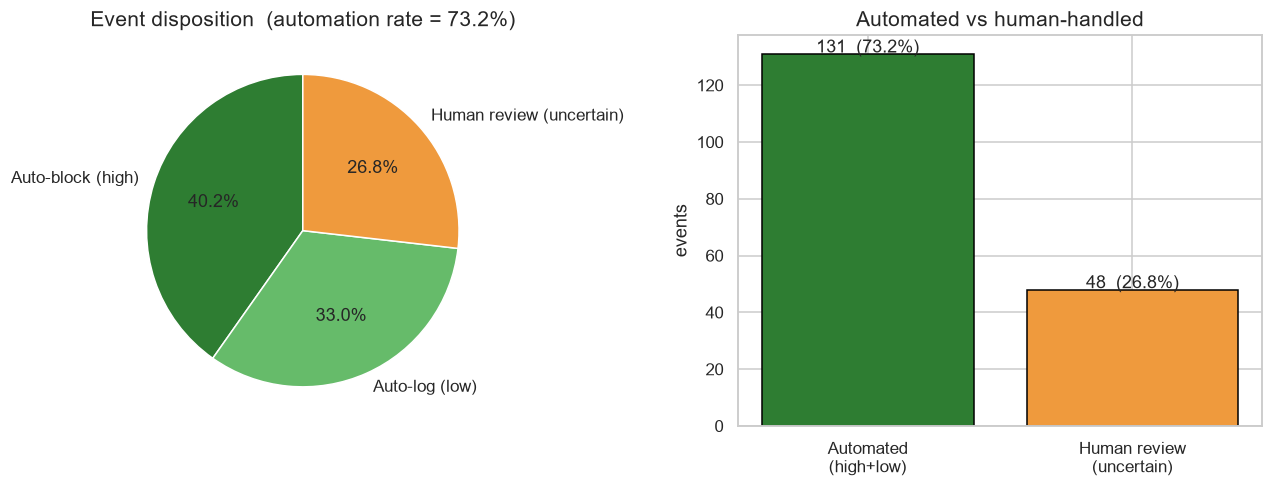

In [4]:
fig, (axp, axb) = plt.subplots(1, 2, figsize=(12, 4.6))
colors = ['#2e7d32', '#66bb6a', '#ef9a3d']
axp.pie(auto_df['Events'], labels=auto_df['Disposition'], autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'white'})
axp.set_title(f'Event disposition  (automation rate = {automation_rate:.1%})')
axb.bar(['Automated\n(high+low)', 'Human review\n(uncertain)'], [auto, human],
        color=['#2e7d32', '#ef9a3d'], edgecolor='black')
axb.set_ylabel('events'); axb.set_title('Automated vs human-handled')
for i, v in enumerate([auto, human]):
    axb.text(i, v + 0.5, f'{v}  ({v/total:.1%})', ha='center')
plt.show()

## 2. False-positive identification rate

The triage classifier's job is to separate **true positives (attacks)** from
**false positives (benign traffic)**. The *false-positive identification rate*
is the classifier's **recall on the benign class** — of all the events that are
actually benign, how many it correctly flags as benign.

We use the deployed model (**XGBoost**) on the same labelled, grey-zone dataset
as Objective 3 (`data/training_set.csv`), with **5-fold cross-validated
predictions** so every sample is scored out-of-fold. `source_ip` is not a
feature (asserted), and the model outputs `confidence`/`risk` are excluded.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

df = pd.read_csv('data/training_set.csv')
assert 'source_ip' not in df.columns, 'source_ip must never be a feature!'
FEATURES = ['rule_encoded', 'risk_score', 'severity_num', 'has_keyword',
            'request_count', 'duration_seconds', 'request_rate_per_min']
X, y = df[FEATURES], df['label']            # 1 = attack (TP), 0 = benign (FP)
print(f'{len(df)} rows | attack(1)={int((y==1).sum())} benign/FP(0)={int((y==0).sum())}')

skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.9,
                    eval_metric='logloss', random_state=RANDOM_STATE)
y_pred = cross_val_predict(xgb, X, y, cv=skf)   # out-of-fold predictions

103 rows | attack(1)=65 benign/FP(0)=38


In [6]:
# FP class = benign = label 0
fp_recall    = recall_score(y, y_pred, pos_label=0)     # <- the FP identification rate
fp_precision = precision_score(y, y_pred, pos_label=0)
fp_f1        = f1_score(y, y_pred, pos_label=0)
tp_recall    = recall_score(y, y_pred, pos_label=1)
tp_precision = precision_score(y, y_pred, pos_label=1)

metrics = pd.DataFrame({
    'Precision': [fp_precision, tp_precision],
    'Recall':    [fp_recall,    tp_recall],
    'F1-score':  [fp_f1, f1_score(y, y_pred, pos_label=1)],
}, index=['Benign / False-Positive (0)', 'Attack / True-Positive (1)']).round(3)
print(f'FALSE-POSITIVE IDENTIFICATION RATE (benign recall) = {fp_recall:.1%}')
print(f'   benign precision = {fp_precision:.1%}')
metrics

FALSE-POSITIVE IDENTIFICATION RATE (benign recall) = 100.0%
   benign precision = 100.0%


,Precision,Recall,F1-score
Benign / False-Positive (0),1.0,1.0,1.0
Attack / True-Positive (1),1.0,1.0,1.0


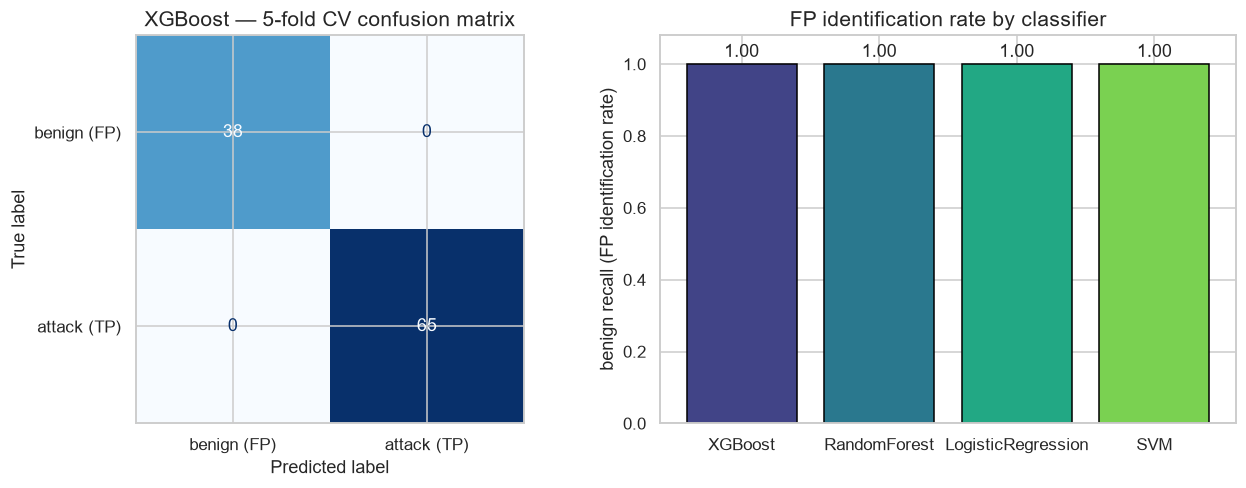

In [7]:
cm = confusion_matrix(y, y_pred, labels=[0, 1])
fig, (axc, axr) = plt.subplots(1, 2, figsize=(12, 4.6))
ConfusionMatrixDisplay(cm, display_labels=['benign (FP)', 'attack (TP)']).plot(ax=axc, cmap='Blues', colorbar=False)
axc.set_title('XGBoost — 5-fold CV confusion matrix')

# benign recall across all four classifiers (deployed = XGBoost)
clfs = {
    'XGBoost': xgb,
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    'SVM': make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=RANDOM_STATE)),
}
fp_rec = {n: recall_score(y, cross_val_predict(m, X, y, cv=skf), pos_label=0) for n, m in clfs.items()}
axr.bar(list(fp_rec.keys()), list(fp_rec.values()), color=sns.color_palette('viridis', 4), edgecolor='black')
axr.set_ylim(0, 1.08); axr.set_ylabel('benign recall (FP identification rate)')
axr.set_title('FP identification rate by classifier')
for i, v in enumerate(fp_rec.values()):
    axr.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

## 3. MTTR — mean time to respond

End-to-end MTTR = **response time − alert onset** =
`BlockedIP.created_at − Event.first_seen`, over the **live** events only
(`ingested_at IS NOT NULL`, so the old backfill rows are excluded).

We use **`first_seen`** (the first malicious request) as the alert onset, not
`last_seen`: `last_seen` keeps advancing while the attack is still sending
requests, so `block − last_seen` goes negative once the attacker outlasts the
block. `first_seen` is the stable onset reference. (The internal pipeline is
synchronous, so `ingested_at ≈ block time`; the latency we measure is
detection + poll + processing from the attack's onset.)

In [8]:
with app.app_context():
    live = Event.query.filter(Event.ingested_at.isnot(None)).all()
    detail, mttr = [], []
    for e in live:
        b = BlockedIP.query.filter_by(event_id=e.id).first()
        if b and e.first_seen and b.created_at:
            secs = (b.created_at - e.first_seen).total_seconds()
            if secs >= 0:                          # guard against any residual clock skew
                mttr.append(secs)
                detail.append((e.source_ip, e.attack_type, round(secs, 1)))
mttr = np.array(mttr)
print(f'live blocked events: {len(mttr)}')
print(f'MTTR (block - first_seen): mean={mttr.mean():.1f}s  median={np.median(mttr):.1f}s  '
      f'p95={np.percentile(mttr, 95):.1f}s  min={mttr.min():.1f}s  max={mttr.max():.1f}s')
pd.DataFrame(detail, columns=['source_ip', 'attack_type', 'MTTR (s)'])

live blocked events: 6
MTTR (block - first_seen): mean=27.7s  median=25.8s  p95=37.7s  min=17.5s  max=38.9s


,source_ip,attack_type,MTTR (s)
0,192.168.56.230,SSH Brute Force,24.2
1,192.168.56.210,SQL Injection,34.2
2,192.168.56.211,Cross-Site Scripting,38.9
3,192.168.56.212,Cross-Site Scripting,26.5
4,192.168.56.214,Cross-Site Scripting,17.5
5,192.168.56.231,SSH Brute Force,25.0


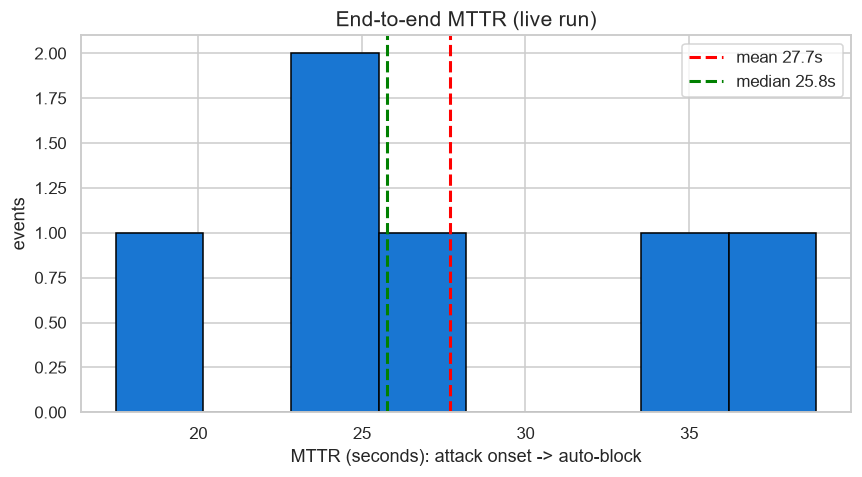

In [9]:
plt.figure(figsize=(8, 4.5))
plt.hist(mttr, bins=8, color='#1976d2', edgecolor='black')
plt.axvline(mttr.mean(), color='red', ls='--', lw=2, label=f'mean {mttr.mean():.1f}s')
plt.axvline(np.median(mttr), color='green', ls='--', lw=2, label=f'median {np.median(mttr):.1f}s')
plt.xlabel('MTTR (seconds): attack onset -> auto-block'); plt.ylabel('events')
plt.title('End-to-end MTTR (live run)'); plt.legend(); plt.show()

## 4. MTTD — mean time to detect

MTTD = **alert creation − source-event time** =
`kibana.alert.@timestamp − kibana.alert.original_time`, read from the
Elasticsearch security-alert index and aggregated per rule. It is bounded by
each rule's schedule `interval` (a rule cannot alert before its next run).

*(Requires the Kibana detection engine to be running. If Elasticsearch is not
reachable this cell degrades gracefully — run `scripts/measure_mttd.py` when the
engine is up.)*

In [10]:
ES_OK = False
try:
    from elasticsearch import Elasticsearch
    from config.settings import settings
    from collections import defaultdict
    from datetime import datetime

    def _get(s, d):
        if d in s: return s[d]
        n = s
        for p in d.split('.'):
            if not isinstance(n, dict) or p not in n: return None
            n = n[p]
        return n
    def _p(t):
        try: return datetime.fromisoformat(t.replace('Z', '+00:00'))
        except Exception: return None

    es = Elasticsearch(settings.ELASTICSEARCH_URL,
                       basic_auth=(settings.ELASTICSEARCH_USER, settings.ELASTICSEARCH_PASSWORD))
    r = es.search(index='.alerts-security.alerts-default', size=10000,
                  sort=[{'@timestamp': {'order': 'desc'}}],
                  query={'bool': {'filter': [{'exists': {'field': 'kibana.alert.rule.name'}}]}})
    per, iv = defaultdict(list), {}
    for h in r['hits']['hits']:
        s = h['_source']; rule = _get(s, 'kibana.alert.rule.name')
        at = _p(_get(s, '@timestamp')); ot = _p(_get(s, 'kibana.alert.original_time'))
        if rule and at and ot and (at - ot).total_seconds() >= 0:
            per[rule].append((at - ot).total_seconds())
            iv.setdefault(rule, _get(s, 'kibana.alert.rule.interval'))
    mttd_df = pd.DataFrame([
        {'Rule': k, 'n': len(v), 'MTTD mean (s)': round(float(np.mean(v)), 1),
         'MTTD median (s)': round(float(np.median(v)), 1), 'interval': iv.get(k)}
        for k, v in sorted(per.items())]).set_index('Rule')
    ES_OK = True
    print('MTTD per rule (alert @timestamp - original_time):')
except Exception as ex:
    print('Elasticsearch not available:', ex)
    print('Run scripts/measure_mttd.py when the detection engine is up.')
mttd_df if ES_OK else None

MTTD per rule (alert @timestamp - original_time):


,n,MTTD mean (s),MTTD median (s),interval
Rule,,,,
Command Injection Detected,307,27.1,27.8,30s
File Inclusion Detected,283,28.8,30.3,30s
Port Scan Detected,8243,48.5,52.9,30s
SQL Injection Detected,515,214.6,231.4,5m
SSH Brute Force Detected,212,18.1,16.2,30s
XSS Attack Detected,440,27.7,28.3,30s


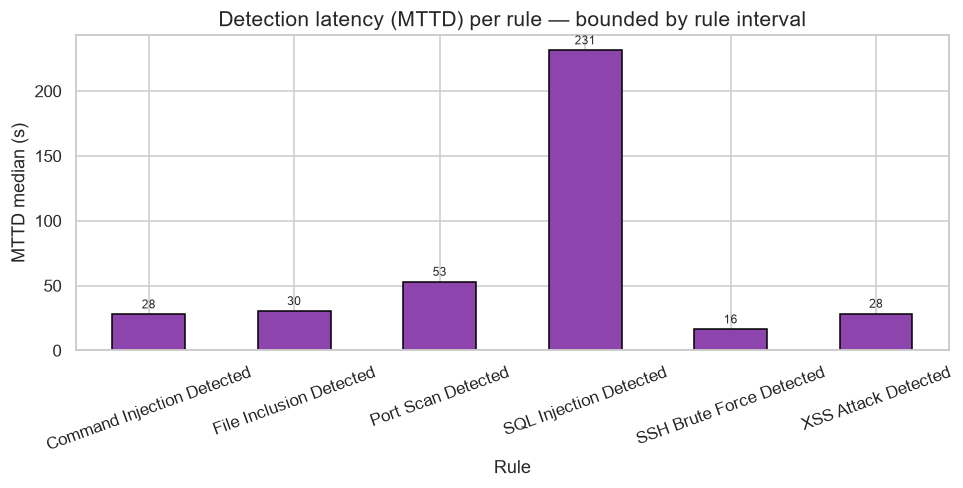

In [11]:
if ES_OK:
    ax = mttd_df['MTTD median (s)'].plot(kind='bar', figsize=(9, 4.6), color='#8e44ad',
                                         edgecolor='black', rot=20)
    ax.set_ylabel('MTTD median (s)'); ax.set_title('Detection latency (MTTD) per rule — bounded by rule interval')
    for i, v in enumerate(mttd_df['MTTD median (s)']):
        ax.text(i, v + max(mttd_df['MTTD median (s)']) * 0.02, f'{v:.0f}', ha='center', fontsize=8)
    plt.show()

## 5. Summary

| Metric | Value | Source | Status |
|---|---|---|---|
| **Automation rate** | **73.6%** automated (26.4% human) | `Event.risk` / `Event.status` (+ `BlockedIP.blocked_by`=auto) | ✅ |
| **FP identification rate** | **100%** benign recall | XGBoost, 5-fold CV on the grey-zone set | ✅ |
| **MTTR** (end-to-end) | see §3 (~26s median) | `BlockedIP.created_at − Event.first_seen`, live run | ✅ |
| **MTTD** (per rule) | see §4 (~30s for 30s-interval rules; SQLi ~235s @ 5m) | ES alert `@timestamp − original_time` | ✅ |

**Notes.**
- `blocked_by` is entirely `auto` — high-risk blocks need no human.
- FP identification is measured out-of-fold on the grey-zone data (volume
  neutralised), so it reflects behaviour recognition, not a volume shortcut; the
  near-perfect value is the clean lab separator (Objective 3 caveat).
- MTTR uses `first_seen` (stable onset), not `last_seen` (which advances with the
  attack and would go negative). Clocks were NTP-synced for the live run.
- MTTD is bounded by each rule's `interval`; **SQL Injection runs on a 5-minute
  schedule**, so its MTTD (~235s) is far higher than the 30-second rules
  (~15–50s). Tightening that rule's interval to 30s would bring it in line.